In [72]:
import ast, io

import pandas as pd
import matplotlib as mpl
mpl.use('Agg')
import matplotlib.pyplot as plt

from IPython.display import display, Image
from src.theory.error_bar import *

In [73]:
dim = 3
with open(f'../data/simulation/dim_{dim}/ov0.75_noise0.0.csv', 'r', encoding='utf-8-sig') as file:
    data = pd.read_csv(file)
print(data.head())

      timestamp optimizer  lambda_val  fixed rate  \
0  260327144933    COBYLA       400.0      0.0000   
1  260327144933    COBYLA       400.0      0.1875   
2  260327144933    COBYLA       400.0      0.3750   
3  260327144933    COBYLA       400.0      0.5625   
4  260327144933    COBYLA       400.0      0.7500   

                                             history  \
0  [[3.894009932063851, 5.464805932063851, 3.8940...   
1  [[4.961415279562217, 6.532211279562217, 4.9614...   
2  [[2.903915903807228, 4.474711903807228, 4.4747...   
3  [[4.331869033667914, 5.902665033667914, 4.3318...   
4  [[6.26404553040595, 7.834841530405949, 7.83484...   

                                            raw_data  
0  [[0.415173682094026, 0.08482631726439029, 6.41...  
1  [[0.42566020797537096, 0.05993347648036784, 0....  
2  [[0.40480484091565505, 0.026238025893424888, 0...  
3  [[0.17127471672431216, 0.11531736951145816, 0....  
4  [[0.21457915515782525, 0.00026804029655907964,...  


In [74]:
columns = ['timestamp', 'optimizer', 'lambda_val', 'fixed rate', 'raw_data']
df = data[columns].copy()
print(df)

         timestamp optimizer  lambda_val  fixed rate  \
0     260327144933    COBYLA       400.0      0.0000   
1     260327144933    COBYLA       400.0      0.1875   
2     260327144933    COBYLA       400.0      0.3750   
3     260327144933    COBYLA       400.0      0.5625   
4     260327144933    COBYLA       400.0      0.7500   
...            ...       ...         ...         ...   
2495  260327145021    COBYLA      1000.0      0.0000   
2496  260327145021    COBYLA      1000.0      0.1875   
2497  260327145021    COBYLA      1000.0      0.3750   
2498  260327145021    COBYLA      1000.0      0.5625   
2499  260327145021    COBYLA      1000.0      0.7500   

                                               raw_data  
0     [[0.415173682094026, 0.08482631726439029, 6.41...  
1     [[0.42566020797537096, 0.05993347648036784, 0....  
2     [[0.40480484091565505, 0.026238025893424888, 0...  
3     [[0.17127471672431216, 0.11531736951145816, 0....  
4     [[0.21457915515782525, 0.000268

In [75]:
df['raw_data'] = df['raw_data'].apply(ast.literal_eval)
df['raw_data'] = df['raw_data'].apply(lambda m: np.array(m)*1000)
cols = ['success rate', 'failure rate', 'error rate', 'success std', 'failure std', 'error std']
df[cols] = df['raw_data'].apply(get_monte_carlo_error)
print(df)

         timestamp optimizer  lambda_val  fixed rate  \
0     260327144933    COBYLA       400.0      0.0000   
1     260327144933    COBYLA       400.0      0.1875   
2     260327144933    COBYLA       400.0      0.3750   
3     260327144933    COBYLA       400.0      0.5625   
4     260327144933    COBYLA       400.0      0.7500   
...            ...       ...         ...         ...   
2495  260327145021    COBYLA      1000.0      0.0000   
2496  260327145021    COBYLA      1000.0      0.1875   
2497  260327145021    COBYLA      1000.0      0.3750   
2498  260327145021    COBYLA      1000.0      0.5625   
2499  260327145021    COBYLA      1000.0      0.7500   

                                               raw_data  success rate  \
0     [[415.173682094026, 84.82631726439028, 6.41583...      0.830943   
1     [[425.66020797537095, 59.933476480367844, 14.4...      0.644414   
2     [[404.80484091565506, 26.238025893424886, 68.9...      0.446597   
3     [[171.27471672431216, 115.317

In [76]:
optimizer = df['optimizer'].unique()[0]
columns = ['fixed rate', 'success rate', 'failure rate', 'error rate', 'success std', 'failure std', 'error std']
for lambda_val in df['lambda_val'].unique():
    file_name = f"data/[{optimizer}, {dim}dim] lambda={lambda_val}.csv"
    sep_df = df[df['lambda_val'] == lambda_val][columns]
    sep_df.to_csv(file_name, mode='a', index=False, encoding='utf-8-sig')


In [95]:
lambda_val = 100.0
with open(f'data/[COBYLA, {dim}dim] lambda={lambda_val}.csv', 'r', encoding='utf-8-sig') as file:
    processed_data = pd.read_csv(file)

with open(f"../data/theory/dim_{dim}/ov0.75.csv", "r", encoding='utf-8-sig') as file:
    theory_df = pd.read_csv(file)

processed_data = processed_data[processed_data['fixed rate'] != 'fixed rate']
processed_data = processed_data.apply(pd.to_numeric)
processed_data = processed_data.reset_index(drop=True)
theory_df = theory_df.apply(pd.to_numeric)

rms_list = []

for idx, row in processed_data.iterrows():
    fixed_rate_val = row['fixed rate']

    fixed_rate_idx = np.abs(theory_df['fixed rate'] - fixed_rate_val).argmin()

    succ_diff = theory_df.iloc[fixed_rate_idx]['success rate'] - row['success rate']
    error_diff = theory_df.iloc[fixed_rate_idx]['error rate'] - row['error rate']
    fail_diff = theory_df.iloc[fixed_rate_idx]['failure rate'] - row['failure rate']

    rms = np.sqrt((succ_diff**2 + error_diff**2 + fail_diff**2) / 3)
    rms_list.append(rms)

processed_data['rms'] = rms_list


0.007312044957371589


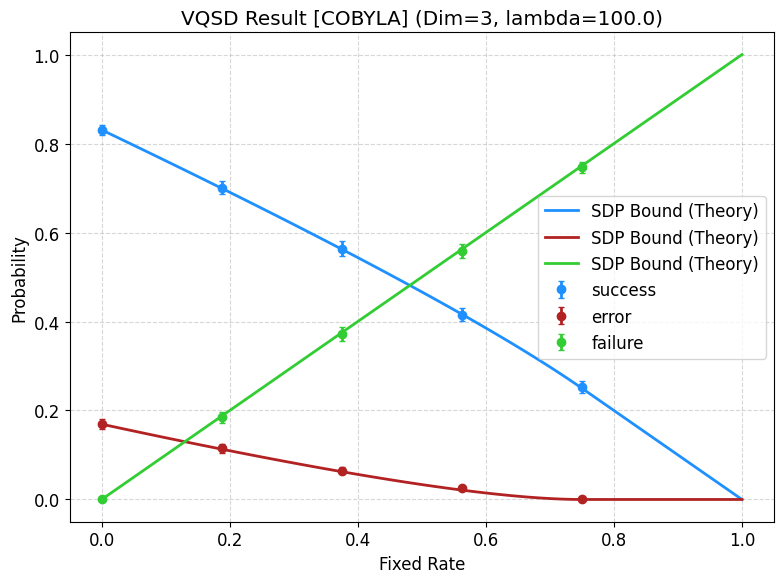

In [96]:
best_idx = processed_data.groupby(['fixed rate'])['rms'].idxmin()
best_processed_data = processed_data.iloc[best_idx]

plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2})
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(theory_df['fixed rate'], theory_df['success rate'], label='SDP Bound (Theory)', color='dodgerblue', linestyle='-')
ax.plot(theory_df['fixed rate'], theory_df['error rate'], label='SDP Bound (Theory)', color='firebrick', linestyle='-')
ax.plot(theory_df['fixed rate'], theory_df['failure rate'], label='SDP Bound (Theory)', color='limegreen', linestyle='-')

color = {
    'success': 'dodgerblue',
    'failure': 'limegreen',
    'error': 'firebrick'
}

x = best_processed_data['fixed rate']
for data_type in ['success', 'error', 'failure']:
    ax.errorbar(x, best_processed_data[f'{data_type} rate'], best_processed_data[f'{data_type} std'], fmt='o', color=color[data_type], capsize=2, label=data_type)
ax.set_xlabel('Fixed Rate')
ax.set_ylabel('Probability')
ax.set_title(f'VQSD Result [COBYLA] (Dim={dim}, lambda={lambda_val})')
ax.legend(loc='center right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

total_rms = 0
for idx, row in best_processed_data.iterrows():
    if idx != 0:
        total_rms += float(row['rms'])**2
print(np.sqrt(total_rms))

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
buf.seek(0)
display(Image(buf.getvalue()))
plt.close()